## This notebook was used to generate noise/outlier detection visualizations for the example report (lifestyle data)

In [1]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

df.head()

df.columns


Index(['ParticipantID', 'Age', 'Location', 'DietType', 'LocalFoodFrequency',
       'TransportationMode', 'EnergySource', 'HomeType', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'Gender', 'UsingPlasticProducts',
       'DisposalMethods', 'PhysicalActivities', 'Rating'],
      dtype='object')

In [2]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [3]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [4]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [5]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [6]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [7]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0

In [8]:
df['Rating'] = df['Rating'].astype(int)
#df['Rating'] = "Class " + df['Rating'].astype(str)

### Attempt MAD with very low multiplier (because otherwise no noise is detected)

In [9]:
# use MAD only for continuous variables, preferably the most 
# impactful one towards the target variable
variable = "MonthlyElectricityConsumption"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 2.0 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,ParticipantID,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
6,7,25,3,600,0,1,5,2.0,80,1200,...,0,0,0,0,1,0,0,0,1,0
206,207,25,3,600,0,1,5,2.0,80,1200,...,0,0,0,0,1,0,0,0,1,0
223,224,61,1,1453,0,0,4,0.0,71,3414,...,0,0,1,0,0,0,0,1,0,0
229,230,66,0,1233,0,1,1,1.0,80,2824,...,1,0,0,0,0,0,1,0,1,0
267,268,64,2,590,2,1,5,1.0,78,4035,...,1,0,0,1,0,0,1,0,0,1
289,290,28,1,1351,0,1,4,0.0,58,3747,...,0,0,0,0,0,1,0,0,1,0
292,293,28,1,1978,0,1,5,0.0,69,3579,...,1,0,0,0,1,0,0,0,0,1
294,295,38,2,486,2,1,5,0.0,79,2228,...,1,0,1,0,0,1,0,0,1,0
301,302,40,1,1630,0,0,5,2.0,67,1079,...,0,1,0,1,1,0,0,0,0,0
303,304,33,3,2094,2,1,5,1.0,59,3680,...,0,1,0,1,0,0,1,0,1,0


In [10]:
print(len(inliers))
print(len(noise))

485
14


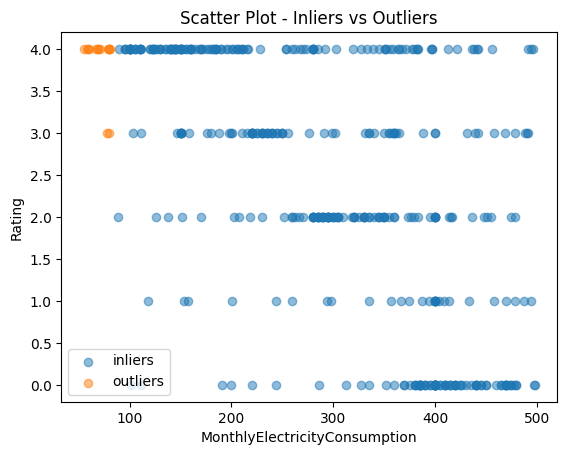

In [11]:
import matplotlib.pyplot as plt

variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = noise.sample(14)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

### Isolation Forest can be used throughout the dataset

In [12]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.075) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 461
Outliers: 38


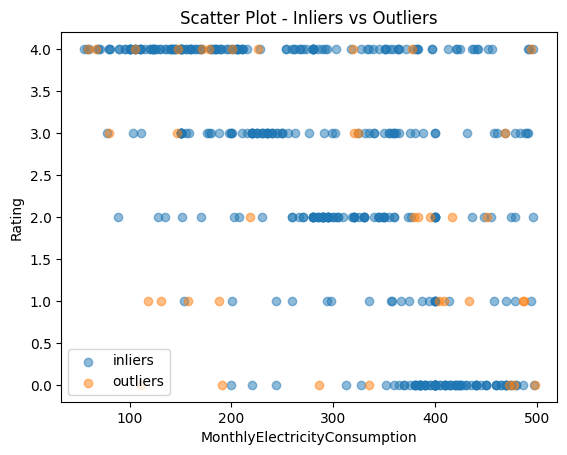

In [13]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = outliers.sample(38)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

<Axes: >

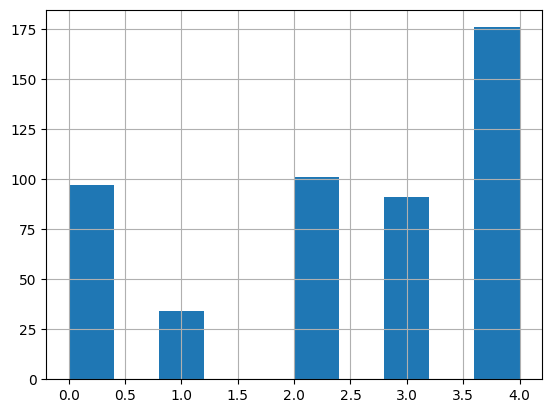

In [14]:
df['Rating'].hist()